# sliceheads — Explainability (XAI)

This notebook uses **`hd5_with_mask_vector.h5`**, which extends the benchmark dataset with real
per-slice ground-truth annotations (`important_slices`) on 50 test samples.

**All localization charts are computed only on samples that each head predicted correctly.**  
This ensures importance scores are evaluated in the regime where the head actually made the right
call — a misclassified sample's importance vector may reflect a spurious or degenerate decision
boundary rather than genuine localization.

Sections:
1. Annotation coverage
2. Build per-head correct-prediction subsets
3. Single-sample deep dive (samples correct for all focus heads)
4. Localization metrics per head (correct-only)
5. Bar charts: rank heads by Spearman r and top-10% recall
6. Classification AUC vs localization quality
7. LOO vs native attention on annotated + correct samples
8. Gallery: best and worst localizations (GeM, correct-only)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr

from sliceheads.explain import localization_metrics
from sliceheads.constants import IMPORTANCE_FILENAME

H5_PATH      = '../hd5_with_mask_vector.h5'
IMP_PATH     = f'../results/{IMPORTANCE_FILENAME}'
PREDS_PATH   = '../results/test_predictions.csv'
METRICS_PATH = '../results/metrics.csv'

print('Setup complete.')

Setup complete.


## 1 — Annotation coverage

Annotated test samples : 50
Annotated slices/sample: min=1  median=15  max=36
Fraction annotated     : min=0.02  median=0.40  max=0.80


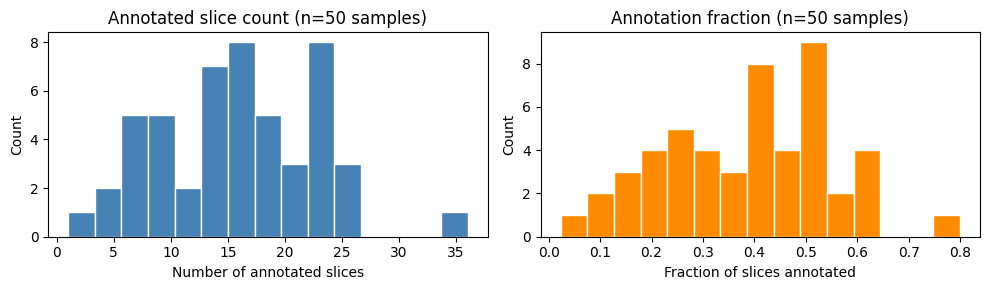

In [2]:
# Load all annotated test samples and their ground-truth masks
gt_masks = {}   # sample_id -> uint8 [N]

with h5py.File(H5_PATH, 'r') as f:
    for sid in f.keys():
        grp = f[sid]
        if str(grp.attrs.get('split', '')) != 'test':
            continue
        mask = grp['important_slices'][:].astype(np.uint8)
        if len(mask) > 0 and mask.sum() > 0:
            gt_masks[sid] = mask

ann_ids = list(gt_masks.keys())
n_important = [int(m.sum()) for m in gt_masks.values()]
frac_imp    = [m.mean() for m in gt_masks.values()]

print(f'Annotated test samples : {len(ann_ids)}')
print(f'Annotated slices/sample: min={min(n_important)}  '
      f'median={int(np.median(n_important))}  max={max(n_important)}')
print(f'Fraction annotated     : min={min(frac_imp):.2f}  '
      f'median={np.median(frac_imp):.2f}  max={max(frac_imp):.2f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.hist(n_important, bins=15, color='steelblue', edgecolor='white')
ax1.set_xlabel('Number of annotated slices')
ax1.set_ylabel('Count')
ax1.set_title('Annotated slice count (n=50 samples)')
ax2.hist(frac_imp, bins=15, color='darkorange', edgecolor='white')
ax2.set_xlabel('Fraction of slices annotated')
ax2.set_ylabel('Count')
ax2.set_title('Annotation fraction (n=50 samples)')
plt.tight_layout()
plt.show()

## 2 — Build per-head correct-prediction subsets

For each head we intersect:
- the 50 annotated test samples, and
- the samples that head predicted correctly (`pred_label == true_label`).

Every subsequent chart uses this head-specific subset.

In [3]:
preds_df = pd.read_csv(PREDS_PATH)

# Only annotated samples
ann_set = set(ann_ids)
preds_ann = preds_df[preds_df['sample_id'].isin(ann_set)].copy()
preds_ann['correct'] = preds_ann['true_label'] == preds_ann['pred_label']

# per-head dict: head_name -> list[sample_id] (annotated AND correctly predicted)
correct_ids = {}
for hn, grp in preds_ann.groupby('head_name'):
    correct_ids[hn] = grp[grp['correct']]['sample_id'].tolist()

with h5py.File(IMP_PATH, 'r') as f:
    all_heads = list(f.keys())

print(f'Head                           annotated  correct  %correct')
print('-' * 60)
for hn in all_heads:
    n_corr = len(correct_ids.get(hn, []))
    pct    = 100 * n_corr / len(ann_ids)
    print(f'{hn:<32s} {len(ann_ids):>9d}  {n_corr:>7d}  {pct:>6.1f}%')

Head                           annotated  correct  %correct
------------------------------------------------------------
ABMILClassifier                         50       40    80.0%
ALSTMFCNClassifier                      50       37    74.0%
DSMILClassifier                         50       40    80.0%
GatedABMILClassifier                    50       38    76.0%
GeMPoolClassifier                       50       44    88.0%
InceptionTimeClassifier                 50       40    80.0%
MaxPoolClassifier                       50       43    86.0%
MeanPoolClassifier                      50       43    86.0%
MultiRocketHydraClassifier              50       40    80.0%
TransformerMILClassifier                50       41    82.0%


## 3 — Single-sample deep dive

We pick a sample that was correctly predicted by **all four focus heads** so that all panels
are directly comparable.

Samples correct for all 4 focus heads: 38
Using sample: study_0255  N=38  annotated_slices=21


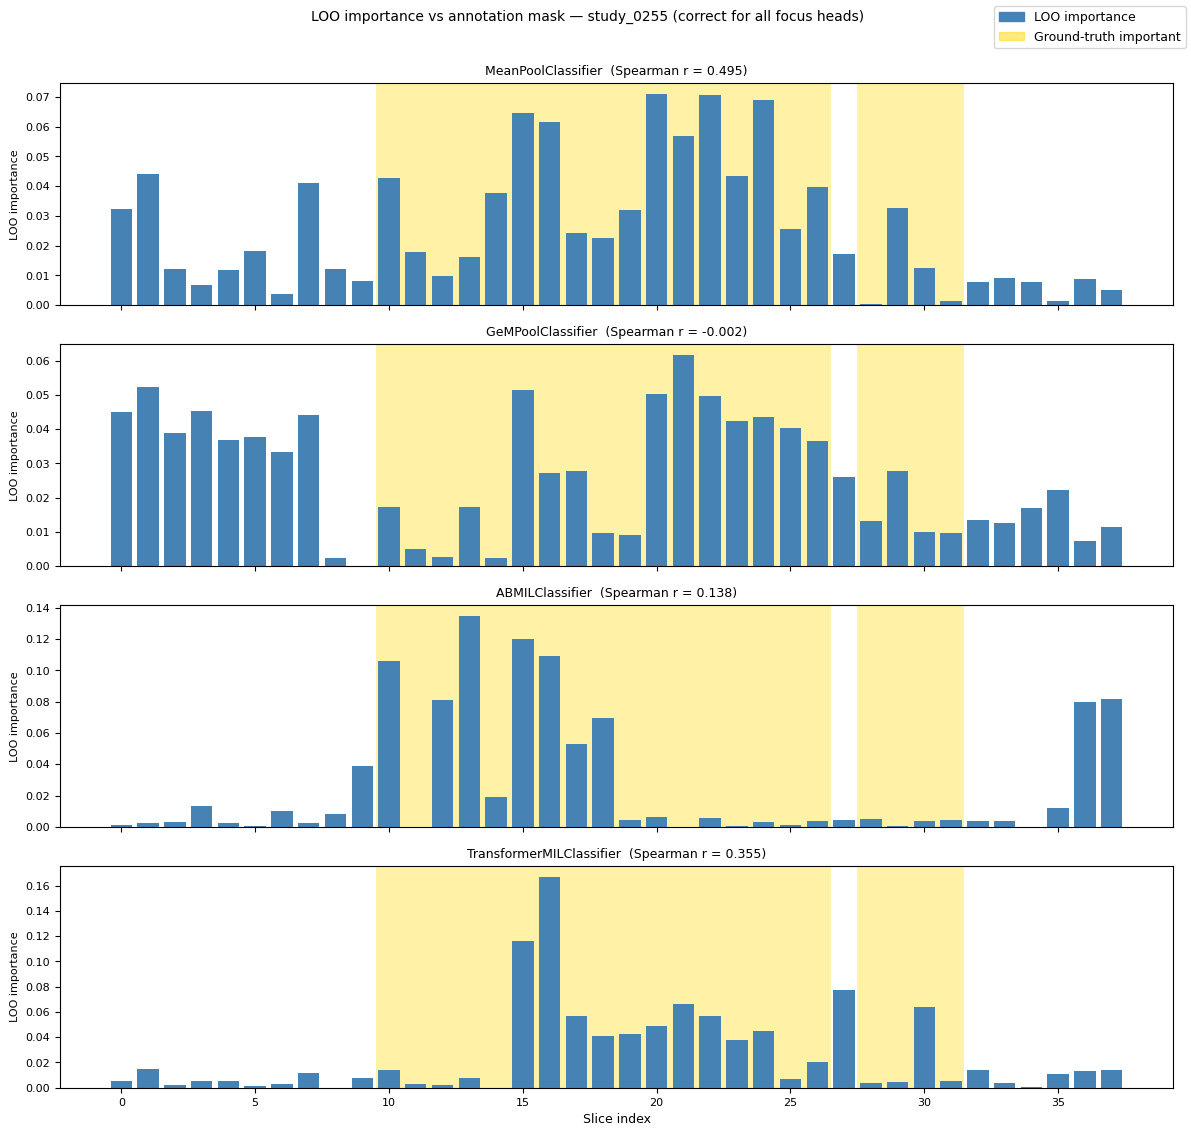

In [4]:
FOCUS_HEADS = ['MeanPoolClassifier', 'GeMPoolClassifier',
               'ABMILClassifier', 'TransformerMILClassifier']

# Samples correct for all focus heads
correct_all_focus = set(correct_ids.get(FOCUS_HEADS[0], []))
for hn in FOCUS_HEADS[1:]:
    correct_all_focus &= set(correct_ids.get(hn, []))

print(f'Samples correct for all {len(FOCUS_HEADS)} focus heads: {len(correct_all_focus)}')

SAMPLE_ID = sorted(correct_all_focus)[0]
gt_mask   = gt_masks[SAMPLE_ID]
N         = len(gt_mask)
print(f'Using sample: {SAMPLE_ID}  N={N}  annotated_slices={int(gt_mask.sum())}')

with h5py.File(IMP_PATH, 'r') as f:
    imp_focus = {hn: f[hn][SAMPLE_ID]['importance'][:] for hn in FOCUS_HEADS}

fig, axes = plt.subplots(len(FOCUS_HEADS), 1,
                         figsize=(12, 2.8 * len(FOCUS_HEADS)), sharex=True)
for ax, hn in zip(axes, FOCUS_HEADS):
    imp = imp_focus[hn]
    for i, v in enumerate(gt_mask):
        if v:
            ax.axvspan(i - 0.5, i + 0.5, color='gold', alpha=0.35, linewidth=0)
    ax.bar(range(N), imp, color='steelblue', width=0.8)
    r, _ = spearmanr(imp, gt_mask.astype(float))
    ax.set_title(f'{hn}  (Spearman r = {r:.3f})', fontsize=9)
    ax.set_ylabel('LOO importance', fontsize=8)
    ax.tick_params(labelsize=8)
axes[-1].set_xlabel('Slice index', fontsize=9)

gold_p = mpatches.Patch(color='gold', alpha=0.5, label='Ground-truth important')
blue_p = mpatches.Patch(color='steelblue', label='LOO importance')
fig.legend(handles=[blue_p, gold_p], loc='upper right', fontsize=9)
fig.suptitle(f'LOO importance vs annotation mask — {SAMPLE_ID} (correct for all focus heads)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

## 4 — Localization metrics (correct predictions only)

For each head we compute Spearman r and top-10% recall on its own correct-prediction subset.

In [5]:
loc_rows = []
with h5py.File(IMP_PATH, 'r') as fi:
    for hn in all_heads:
        subset = correct_ids.get(hn, [])
        spearman_scores, recall_scores, precision_scores = [], [], []
        for sid in subset:
            imp  = fi[hn][sid]['importance'][:]
            mask = gt_masks[sid]
            lm   = localization_metrics(imp, mask, top_fraction=0.10)
            if lm:
                spearman_scores.append(lm['spearman_correlation'])
                recall_scores.append(lm['top_10_pct_recall'])
                precision_scores.append(lm['top_10_pct_precision'])

        loc_rows.append({
            'Head': hn,
            'n_correct':          len(subset),
            'Spearman_mean':      np.mean(spearman_scores)   if spearman_scores   else np.nan,
            'Spearman_std':       np.std(spearman_scores)    if spearman_scores   else np.nan,
            'Recall@10%_mean':    np.mean(recall_scores)     if recall_scores     else np.nan,
            'Recall@10%_std':     np.std(recall_scores)      if recall_scores     else np.nan,
            'Precision@10%_mean': np.mean(precision_scores)  if precision_scores  else np.nan,
            'Precision@10%_std':  np.std(precision_scores)   if precision_scores  else np.nan,
        })

df_loc = (
    pd.DataFrame(loc_rows)
    .set_index('Head')
    .sort_values('Spearman_mean', ascending=False)
)
print('Localization metrics (correct predictions only):\n')
print(df_loc.round(3).to_string())

Localization metrics (correct predictions only):

                            n_correct  Spearman_mean  Spearman_std  Recall@10%_mean  Recall@10%_std  Precision@10%_mean  Precision@10%_std
Head                                                                                                                                      
ALSTMFCNClassifier                 37          0.365         0.160            0.221           0.078               0.757              0.228
ABMILClassifier                    40          0.219         0.198            0.149           0.091               0.497              0.221
TransformerMILClassifier           41          0.209         0.170            0.169           0.082               0.578              0.228
MeanPoolClassifier                 43          0.178         0.199            0.154           0.083               0.553              0.294
InceptionTimeClassifier            40          0.161         0.251            0.190           0.127               0.

## 5 — Rank heads by localization quality

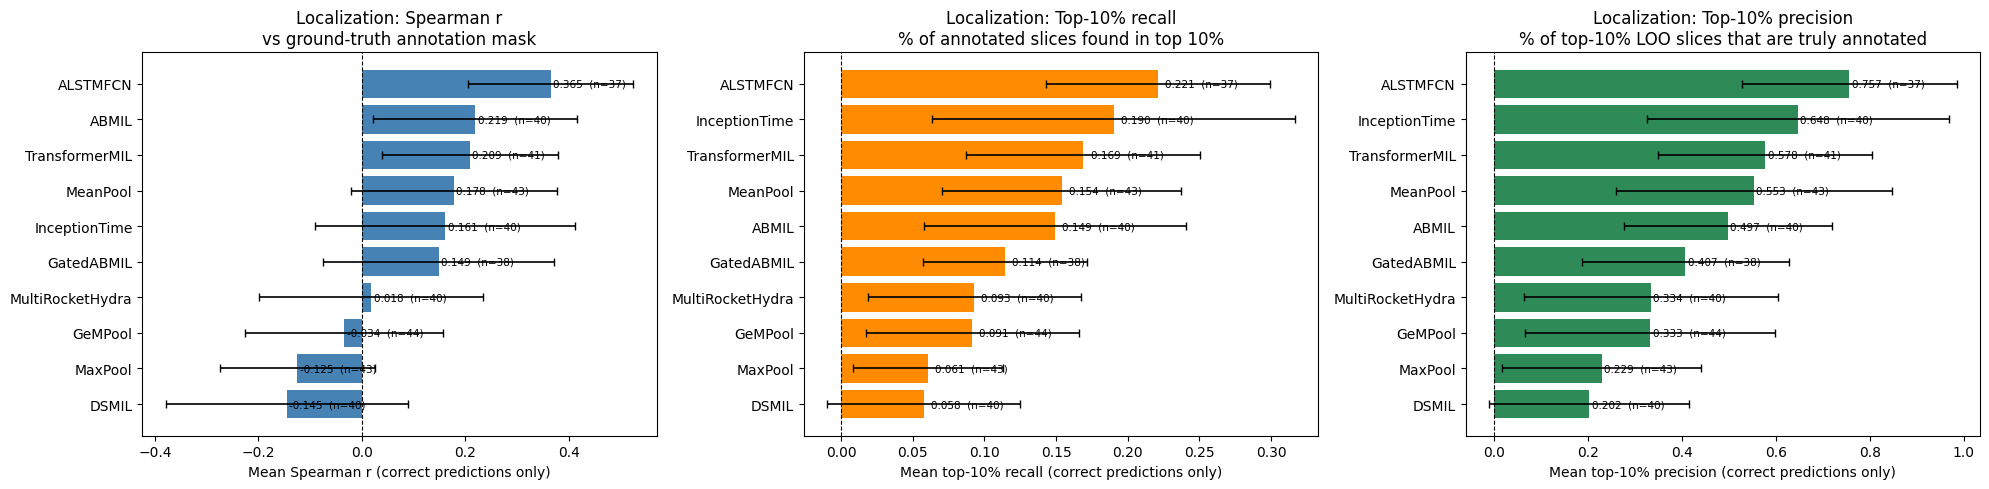

In [6]:
short = [hn.replace('Classifier', '') for hn in df_loc.index]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

# --- Spearman r ---
means_s = df_loc['Spearman_mean'].values
stds_s  = df_loc['Spearman_std'].values
bars = ax1.barh(short, means_s, xerr=stds_s, color='steelblue',
                error_kw={'elinewidth': 1.2, 'capsize': 3})
ax1.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Mean Spearman r (correct predictions only)')
ax1.set_title('Localization: Spearman r\nvs ground-truth annotation mask')
ax1.invert_yaxis()
for bar, val, n in zip(bars, means_s, df_loc['n_correct']):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}  (n={n})', va='center', fontsize=7.5)

# --- Top-10% Recall ---
df_rec    = df_loc.sort_values('Recall@10%_mean', ascending=False)
short_rec = [hn.replace('Classifier', '') for hn in df_rec.index]
means_r   = df_rec['Recall@10%_mean'].values
stds_r    = df_rec['Recall@10%_std'].values
bars2 = ax2.barh(short_rec, means_r, xerr=stds_r, color='darkorange',
                 error_kw={'elinewidth': 1.2, 'capsize': 3})
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Mean top-10% recall (correct predictions only)')
ax2.set_title('Localization: Top-10% recall\n% of annotated slices found in top 10%')
ax2.invert_yaxis()
for bar, val, n in zip(bars2, means_r, df_rec['n_correct']):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}  (n={n})', va='center', fontsize=7.5)

# --- Top-10% Precision ---
df_prec    = df_loc.sort_values('Precision@10%_mean', ascending=False)
short_prec = [hn.replace('Classifier', '') for hn in df_prec.index]
means_p    = df_prec['Precision@10%_mean'].values
stds_p     = df_prec['Precision@10%_std'].values
bars3 = ax3.barh(short_prec, means_p, xerr=stds_p, color='seagreen',
                 error_kw={'elinewidth': 1.2, 'capsize': 3})
ax3.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax3.set_xlabel('Mean top-10% precision (correct predictions only)')
ax3.set_title('Localization: Top-10% precision\n% of top-10% LOO slices that are truly annotated')
ax3.invert_yaxis()
for bar, val, n in zip(bars3, means_p, df_prec['n_correct']):
    ax3.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}  (n={n})', va='center', fontsize=7.5)

plt.tight_layout()
plt.show()

## 6 — Classification AUC vs localization quality

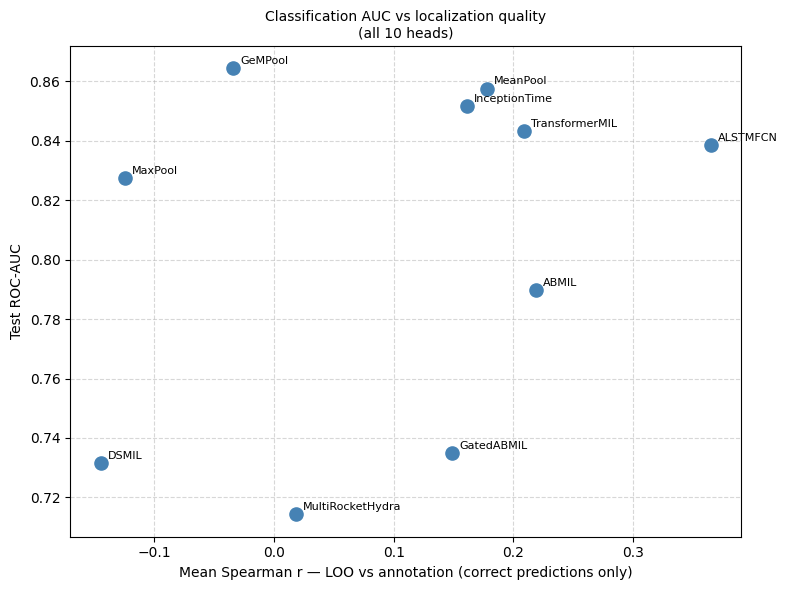

In [7]:
metrics_df = pd.read_csv(METRICS_PATH).set_index('head_name')

roc_aucs    = [float(metrics_df.loc[hn, 'roc_auc']) for hn in df_loc.index]
spear_means = df_loc['Spearman_mean'].values
short_all   = [hn.replace('Classifier', '') for hn in df_loc.index]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(spear_means, roc_aucs, s=90, color='steelblue', zorder=3)
for name, x, y in zip(short_all, spear_means, roc_aucs):
    ax.annotate(name, (x, y), fontsize=8, xytext=(5, 3), textcoords='offset points')
ax.set_xlabel('Mean Spearman r — LOO vs annotation (correct predictions only)', fontsize=10)
ax.set_ylabel('Test ROC-AUC', fontsize=10)
ax.set_title('Classification AUC vs localization quality\n(all 10 heads)', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7 — LOO vs native attention (MIL heads, correct predictions only)

Per-sample deep dive for the same example as section 3, then aggregated across all
annotated + correctly predicted samples for each MIL head.

MIL heads with native attention: ['ABMILClassifier', 'ALSTMFCNClassifier', 'DSMILClassifier', 'GatedABMILClassifier']
Samples correct for all attention heads: 24
Sample: study_0255  N=38  annotated=21


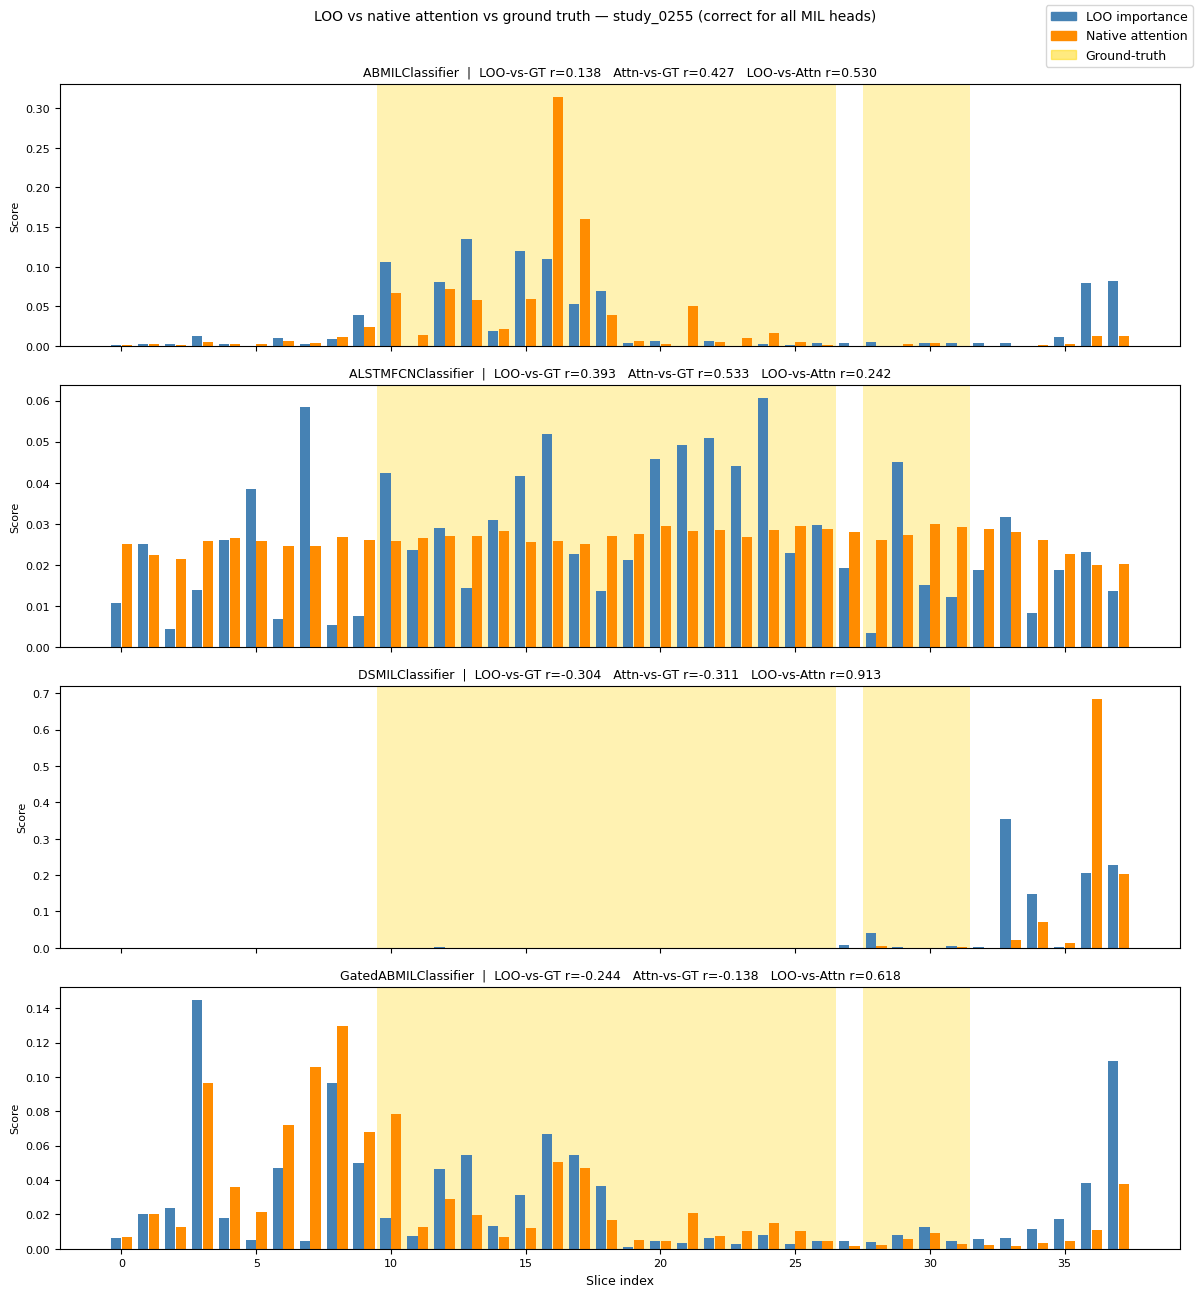

In [8]:
with h5py.File(IMP_PATH, 'r') as f:
    ATTN_HEADS = [
        hn for hn in all_heads
        if 'native_attention' in f[hn][ann_ids[0]]
    ]
print('MIL heads with native attention:', ATTN_HEADS)

# Use sample correct for ALL attention heads
correct_all_attn = set(correct_ids.get(ATTN_HEADS[0], []))
for hn in ATTN_HEADS[1:]:
    correct_all_attn &= set(correct_ids.get(hn, []))
print(f'Samples correct for all attention heads: {len(correct_all_attn)}')

ATT_SAMPLE = sorted(correct_all_attn)[0]
gt_attn    = gt_masks[ATT_SAMPLE]
N_attn     = len(gt_attn)
print(f'Sample: {ATT_SAMPLE}  N={N_attn}  annotated={int(gt_attn.sum())}')

fig, axes = plt.subplots(len(ATTN_HEADS), 1,
                         figsize=(12, 3.2 * len(ATTN_HEADS)), sharex=True)
if len(ATTN_HEADS) == 1:
    axes = [axes]

with h5py.File(IMP_PATH, 'r') as f:
    for ax, hn in zip(axes, ATTN_HEADS):
        loo  = f[hn][ATT_SAMPLE]['importance'][:]
        attn = f[hn][ATT_SAMPLE]['native_attention'][:]
        attn_norm = attn / (attn.sum() + 1e-9)

        for i, v in enumerate(gt_attn):
            if v:
                ax.axvspan(i - 0.5, i + 0.5, color='gold', alpha=0.30, linewidth=0)
        x = np.arange(N_attn)
        ax.bar(x - 0.2, loo,       width=0.38, color='steelblue',  label='LOO importance')
        ax.bar(x + 0.2, attn_norm, width=0.38, color='darkorange', label='Native attention')

        r_loo,  _ = spearmanr(loo,       gt_attn.astype(float))
        r_attn, _ = spearmanr(attn_norm, gt_attn.astype(float))
        r_cross,_ = spearmanr(loo,       attn_norm)
        ax.set_title(
            f'{hn}  |  LOO-vs-GT r={r_loo:.3f}   Attn-vs-GT r={r_attn:.3f}   LOO-vs-Attn r={r_cross:.3f}',
            fontsize=9)
        ax.set_ylabel('Score', fontsize=8)
        ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Slice index', fontsize=9)
gold_p = mpatches.Patch(color='gold',      alpha=0.5, label='Ground-truth')
blue_p = mpatches.Patch(color='steelblue',            label='LOO importance')
oran_p = mpatches.Patch(color='darkorange',            label='Native attention')
fig.legend(handles=[blue_p, oran_p, gold_p], loc='upper right', fontsize=9)
fig.suptitle(f'LOO vs native attention vs ground truth — {ATT_SAMPLE} (correct for all MIL heads)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

                       n  LOO Spearman  Attn Spearman  LOO Recall@10%  Attn Recall@10%  LOO Precision@10%  Attn Precision@10%
Head                                                                                                                         
ABMILClassifier       40         0.219          0.305           0.149            0.183              0.497               0.628
ALSTMFCNClassifier    37         0.365         -0.070           0.221            0.066              0.757               0.276
DSMILClassifier       40        -0.145         -0.192           0.058            0.032              0.202               0.124
GatedABMILClassifier  38         0.149          0.190           0.114            0.140              0.407               0.493


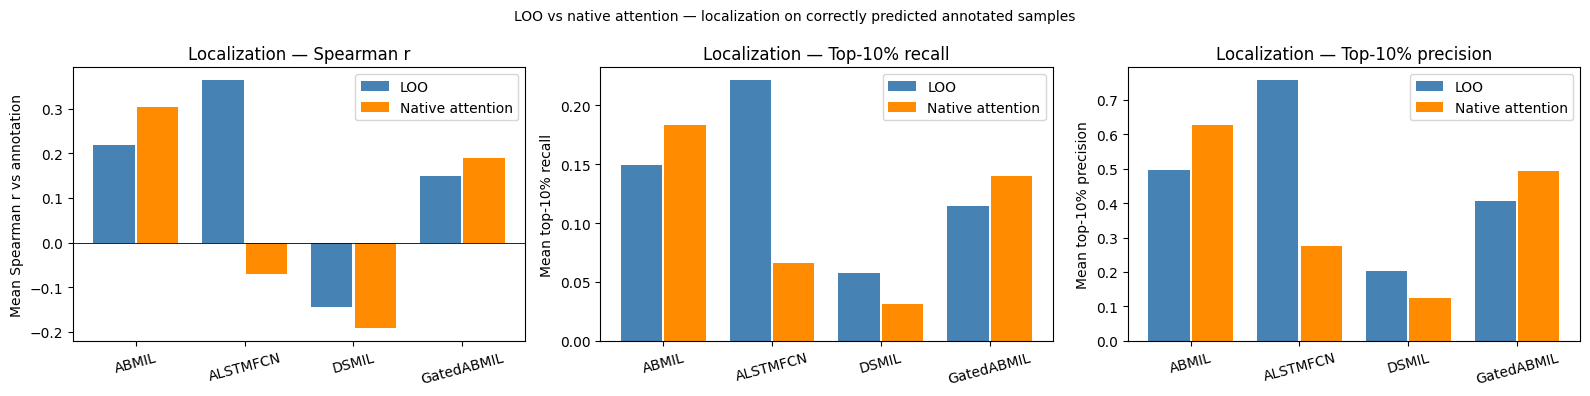

In [9]:
# Aggregated: LOO vs native attention localization on correct subsets
attn_rows = []
with h5py.File(IMP_PATH, 'r') as fi:
    for hn in ATTN_HEADS:
        subset = correct_ids.get(hn, [])
        loo_s, attn_s, loo_r, attn_r, loo_p, attn_p = [], [], [], [], [], []
        for sid in subset:
            mask      = gt_masks[sid]
            loo       = fi[hn][sid]['importance'][:]
            attn      = fi[hn][sid]['native_attention'][:]
            attn_norm = attn / (attn.sum() + 1e-9)
            lm_l = localization_metrics(loo,       mask, top_fraction=0.10)
            lm_a = localization_metrics(attn_norm, mask, top_fraction=0.10)
            if lm_l and lm_a:
                loo_s.append(lm_l['spearman_correlation'])
                attn_s.append(lm_a['spearman_correlation'])
                loo_r.append(lm_l['top_10_pct_recall'])
                attn_r.append(lm_a['top_10_pct_recall'])
                loo_p.append(lm_l['top_10_pct_precision'])
                attn_p.append(lm_a['top_10_pct_precision'])
        attn_rows.append({
            'Head': hn, 'n': len(subset),
            'LOO Spearman':       np.mean(loo_s)  if loo_s  else np.nan,
            'Attn Spearman':      np.mean(attn_s) if attn_s else np.nan,
            'LOO Recall@10%':     np.mean(loo_r)  if loo_r  else np.nan,
            'Attn Recall@10%':    np.mean(attn_r) if attn_r else np.nan,
            'LOO Precision@10%':  np.mean(loo_p)  if loo_p  else np.nan,
            'Attn Precision@10%': np.mean(attn_p) if attn_p else np.nan,
        })

df_attn = pd.DataFrame(attn_rows).set_index('Head')
print(df_attn.round(3).to_string())

x = np.arange(len(ATTN_HEADS))
short_attn = [hn.replace('Classifier', '') for hn in ATTN_HEADS]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

ax1.bar(x - 0.2, df_attn['LOO Spearman'],  width=0.38, color='steelblue',  label='LOO')
ax1.bar(x + 0.2, df_attn['Attn Spearman'], width=0.38, color='darkorange', label='Native attention')
ax1.set_xticks(x); ax1.set_xticklabels(short_attn, rotation=15)
ax1.axhline(0, color='black', linewidth=0.6)
ax1.set_ylabel('Mean Spearman r vs annotation')
ax1.set_title('Localization — Spearman r')
ax1.legend()

ax2.bar(x - 0.2, df_attn['LOO Recall@10%'],  width=0.38, color='steelblue',  label='LOO')
ax2.bar(x + 0.2, df_attn['Attn Recall@10%'], width=0.38, color='darkorange', label='Native attention')
ax2.set_xticks(x); ax2.set_xticklabels(short_attn, rotation=15)
ax2.set_ylabel('Mean top-10% recall')
ax2.set_title('Localization — Top-10% recall')
ax2.legend()

ax3.bar(x - 0.2, df_attn['LOO Precision@10%'],  width=0.38, color='steelblue',  label='LOO')
ax3.bar(x + 0.2, df_attn['Attn Precision@10%'], width=0.38, color='darkorange', label='Native attention')
ax3.set_xticks(x); ax3.set_xticklabels(short_attn, rotation=15)
ax3.set_ylabel('Mean top-10% precision')
ax3.set_title('Localization — Top-10% precision')
ax3.legend()

fig.suptitle('LOO vs native attention — localization on correctly predicted annotated samples',
             fontsize=10)
plt.tight_layout()
plt.show()

## 8 — Gallery: best and worst GeMPool localizations (correct predictions only)

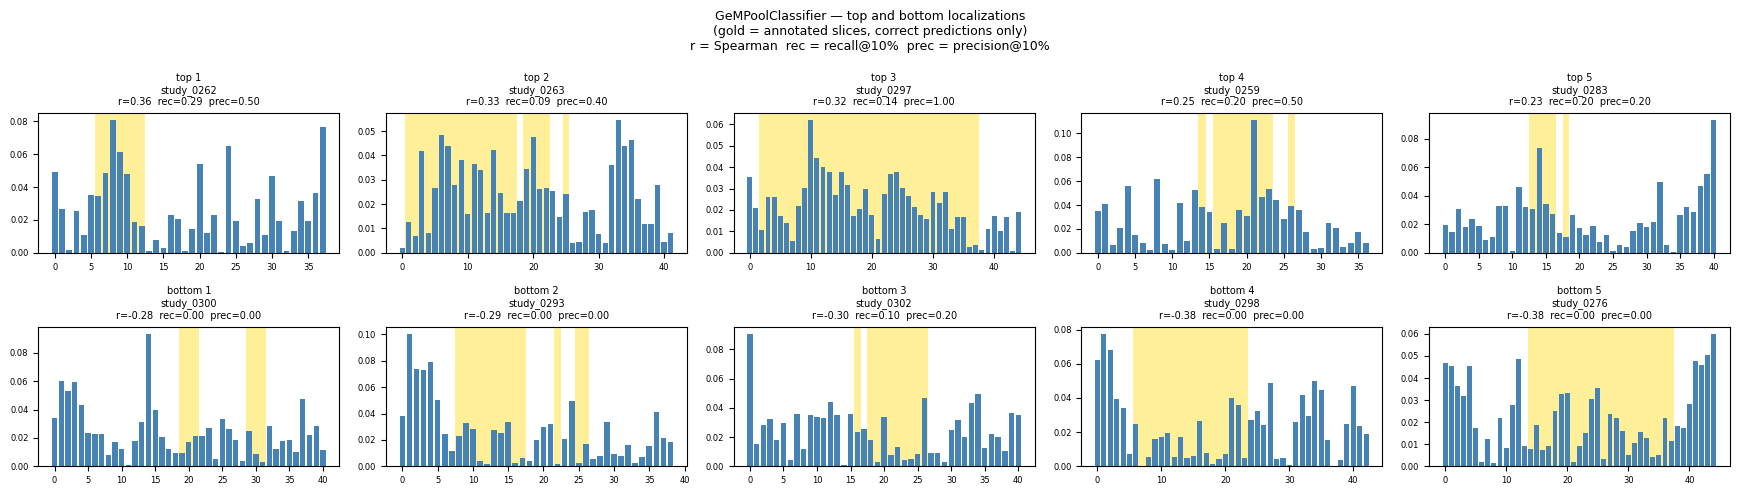

In [10]:
GALLERY_HEAD = 'GeMPoolClassifier'
gallery_subset = correct_ids[GALLERY_HEAD]

sample_scores = []
with h5py.File(IMP_PATH, 'r') as fi:
    for sid in gallery_subset:
        imp = fi[GALLERY_HEAD][sid]['importance'][:]
        lm  = localization_metrics(imp, gt_masks[sid], top_fraction=0.10)
        if lm:
            sample_scores.append((sid, lm['spearman_correlation'],
                                  lm['top_10_pct_recall'], lm['top_10_pct_precision']))

sample_scores.sort(key=lambda x: x[1], reverse=True)
n_show = min(5, len(sample_scores))
gallery_items  = sample_scores[:n_show] + sample_scores[-n_show:]
gallery_labels = [f'top {i+1}' for i in range(n_show)] + [f'bottom {i+1}' for i in range(n_show)]

fig, axes = plt.subplots(2, n_show, figsize=(3.5 * n_show, 5), sharey=False)

with h5py.File(IMP_PATH, 'r') as fi:
    for ax, (sid, r, rec, prec), glabel in zip(axes.flatten(), gallery_items, gallery_labels):
        imp  = fi[GALLERY_HEAD][sid]['importance'][:]
        mask = gt_masks[sid]
        for i, v in enumerate(mask):
            if v:
                ax.axvspan(i - 0.5, i + 0.5, color='gold', alpha=0.40, linewidth=0)
        ax.bar(range(len(imp)), imp, color='steelblue', width=0.8)
        ax.set_title(f'{glabel}\n{sid}\nr={r:.2f}  rec={rec:.2f}  prec={prec:.2f}', fontsize=7)
        ax.tick_params(labelsize=6)

fig.suptitle(f'{GALLERY_HEAD} — top and bottom localizations\n'
             f'(gold = annotated slices, correct predictions only)\n'
             f'r = Spearman  rec = recall@10%  prec = precision@10%',
             fontsize=9)
plt.tight_layout()
plt.show()

## Summary

All localization numbers in this notebook are computed **exclusively on samples each head predicted correctly**, so they reflect the head's explanatory quality in its success regime rather than conflating localization with classification failure.

| Perspective | Tool used |
|---|---|
| Per-head subset | `results/test_predictions.csv` → `pred_label == true_label` |
| Importance scores | `results/importance.h5` (pre-computed LOO) |
| Ground-truth masks | `hd5_with_mask_vector.h5` → `important_slices` |
| Metrics | `localization_metrics(importance, mask, top_fraction=0.10)` |

**Next steps**:
- Try different `top_fraction` values (0.20, 0.30) to see how precision changes with coverage.
- Run `compute_importance_dataset` on a new model and plug its importance scores in here.
- Add more annotated samples to the HDF5 file to reduce variance in the per-head estimates.